In [ ]:
# If needed, uncomment this:
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib openpyxl
#1. Install/import libraries
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [ ]:
#read the Dry Bean dataset
DATA_PATH = "/content/Dry_Bean.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [ ]:
#3. Inspect the dataset
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["Class"].value_counts())

print("Number of duplicate rows:", df.duplicated().sum())

Columns:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness

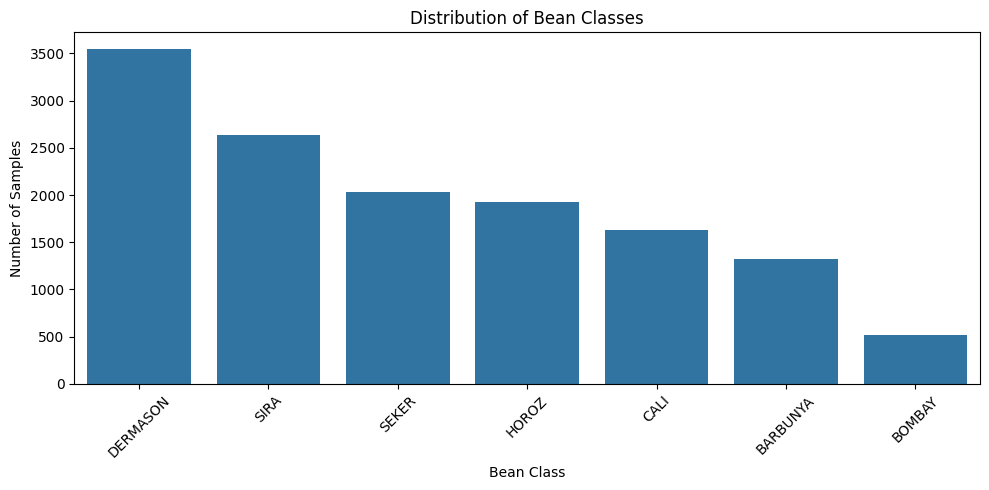

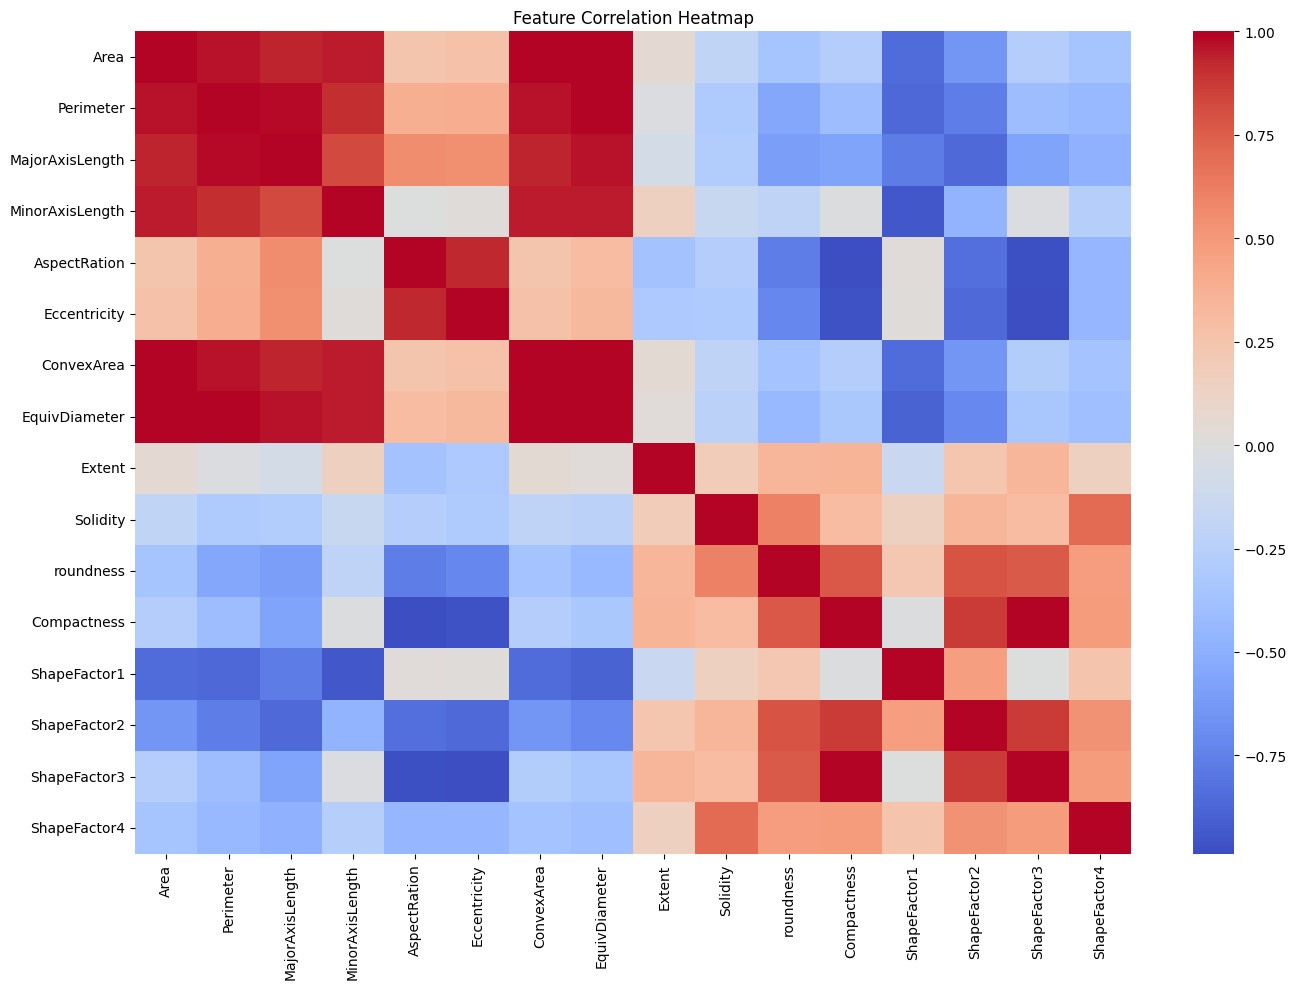

In [ ]:
#Basic EDA
#Class distribution
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Class",
    order=df["Class"].value_counts().index
)

plt.title("Distribution of Bean Classes")
plt.xlabel("Bean Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#Correlation heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.drop(columns=["Class"]).corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
#Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13611, 16)
y shape: (13611,)


In [ ]:
#Encode the target
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

Classes:
0 = BARBUNYA
1 = BOMBAY
2 = CALI
3 = DERMASON
4 = HOROZ
5 = SEKER
6 = SIRA


In [ ]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 10888
Testing samples: 2723


In [ ]:
# Define all 5 models
# For Logistic Regression and KNN, scaling is important.
# Using a Pipeline ensures that scaling is fitted only on the training data, avoiding data leakage.
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

In [ ]:
#Train all models and calculate metrics
results = []

trained_models = {}

for model_name, model in models.items():

    print("=" * 60)
    print("Training:", model_name)

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions for AUC
    y_proba = model.predict_proba(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average="weighted"
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    results.append({
        "ML Model": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    })

    trained_models[model_name] = model

    print(f"Accuracy : {accuracy:.4f}")
    print(f"AUC      : {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"MCC      : {mcc:.4f}")

Training: Logistic Regression
Accuracy : 0.9207
AUC      : 0.9934
Precision: 0.9215
Recall   : 0.9207
F1 Score : 0.9209
MCC      : 0.9042
Training: Decision Tree
Accuracy : 0.8920
AUC      : 0.9334
Precision: 0.8917
Recall   : 0.8920
F1 Score : 0.8916
MCC      : 0.8696
Training: KNN
Accuracy : 0.9166
AUC      : 0.9812
Precision: 0.9174
Recall   : 0.9166
F1 Score : 0.9168
MCC      : 0.8992
Training: Naive Bayes
Accuracy : 0.7639
AUC      : 0.9644
Precision: 0.7654
Recall   : 0.7639
F1 Score : 0.7615
MCC      : 0.7154
Training: Random Forest
Accuracy : 0.9199
AUC      : 0.9921
Precision: 0.9199
Recall   : 0.9199
F1 Score : 0.9198
MCC      : 0.9032


In [ ]:
# Create the comparison table
results_df = pd.DataFrame(results)
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]

results_display[metric_columns] = results_display[metric_columns].round(4)

results_display

,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.9207,0.9934,0.9215,0.9207,0.9209,0.9042
1,Decision Tree,0.8920,0.9334,0.8917,0.8920,0.8916,0.8696
2,KNN,0.9166,0.9812,0.9174,0.9166,0.9168,0.8992
3,Naive Bayes,0.7639,0.9644,0.7654,0.7639,0.7615,0.7154
4,Random Forest,0.9199,0.9921,0.9199,0.9199,0.9198,0.9032


In [ ]:
# Find the overall winner
results_df["Average Score"] = results_df[
    ["Accuracy", "AUC", "Precision", "Recall", "F1 Score", "MCC"]
].mean(axis=1)

winner = results_df.sort_values(
    "Average Score",
    ascending=False
).iloc[0]

print("Overall Winner:", winner["ML Model"])
print("Average Score:", round(winner["Average Score"], 4))

Overall Winner: Logistic Regression
Average Score: 0.9302


In [ ]:
# Classification report for every model
for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )



Logistic Regression
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



Decision Tree
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.91      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.91      0.92       326
    DERMASON       0.88      0.90      0.89       709
       HOROZ       0.94      0.91      0.93       386
       SEKER       0.91      0.95      0

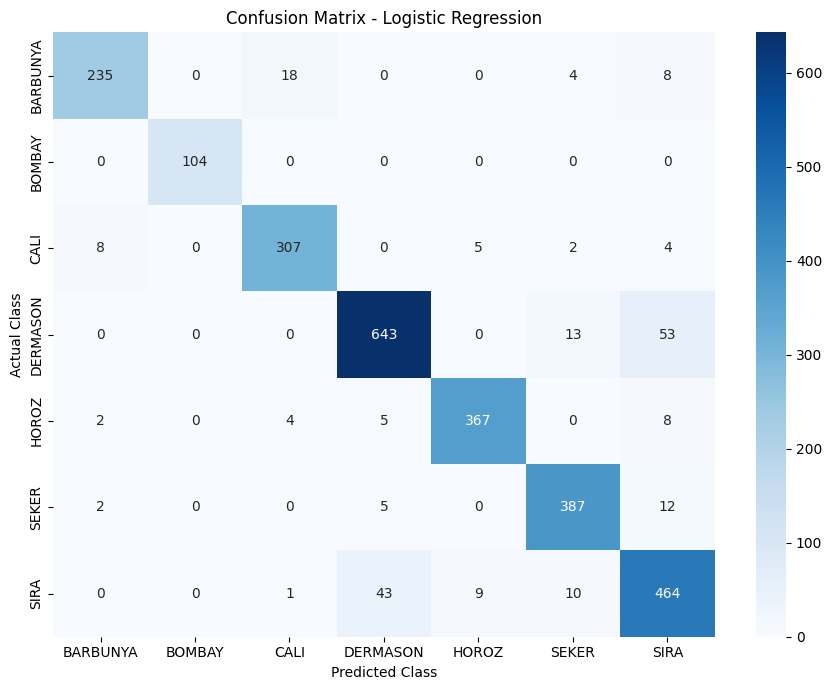

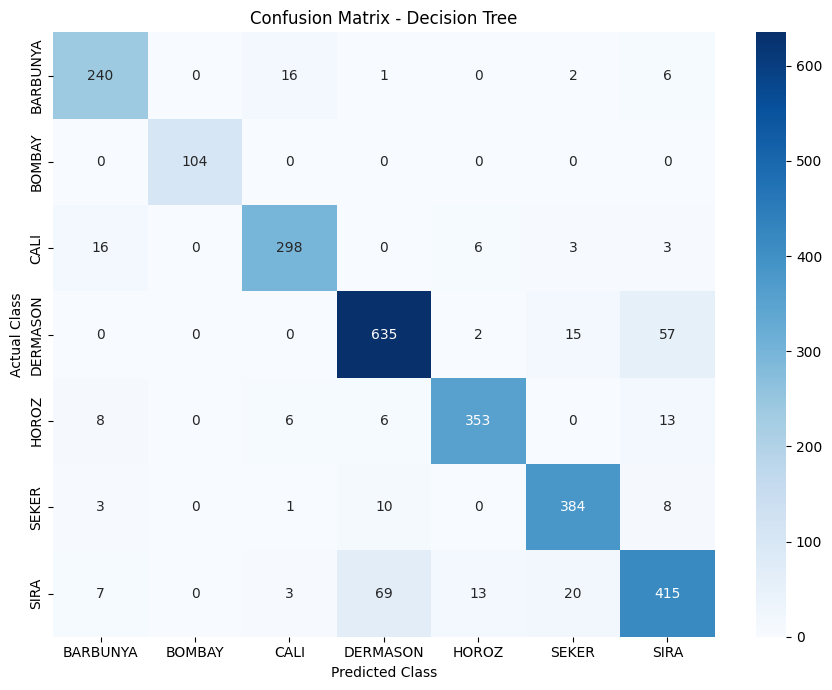

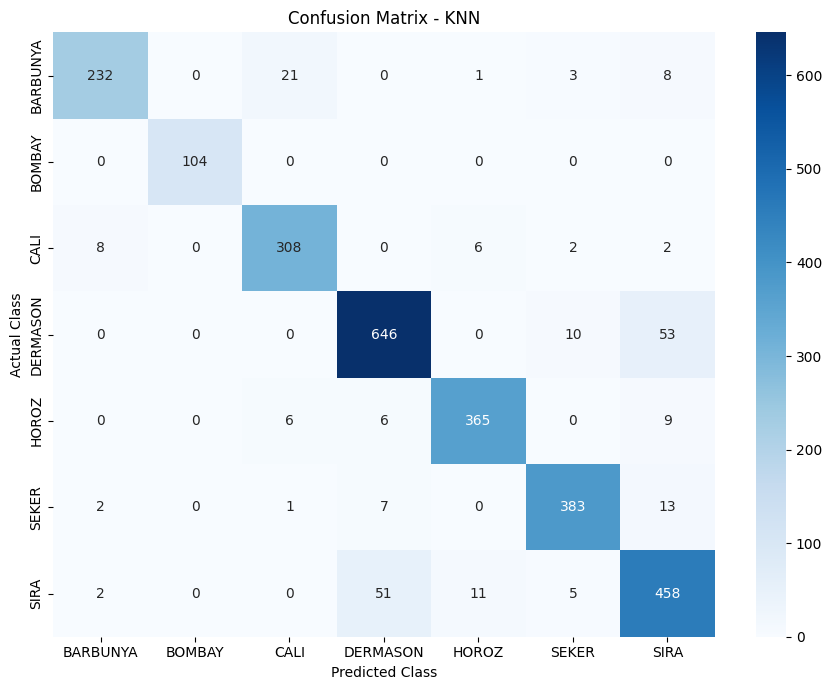

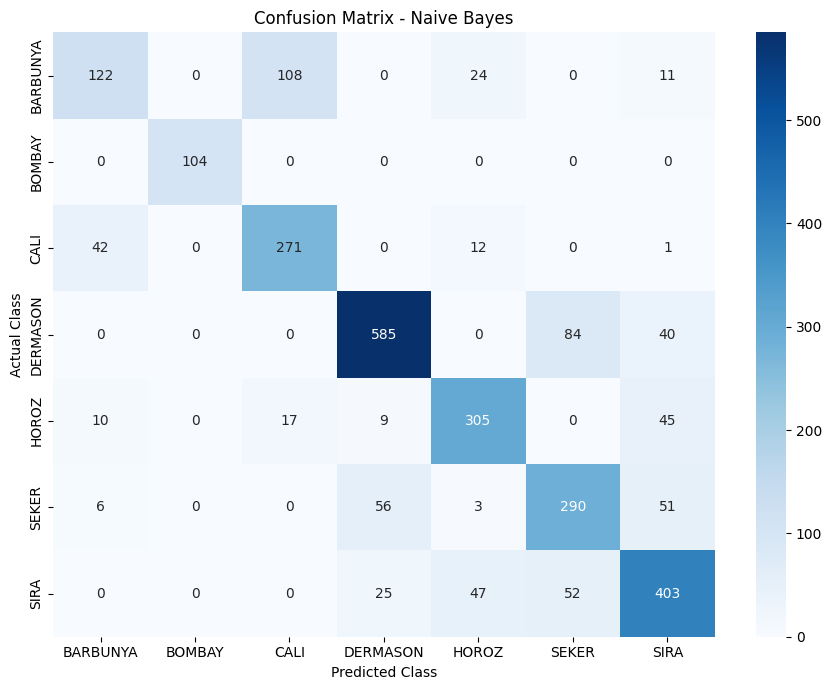

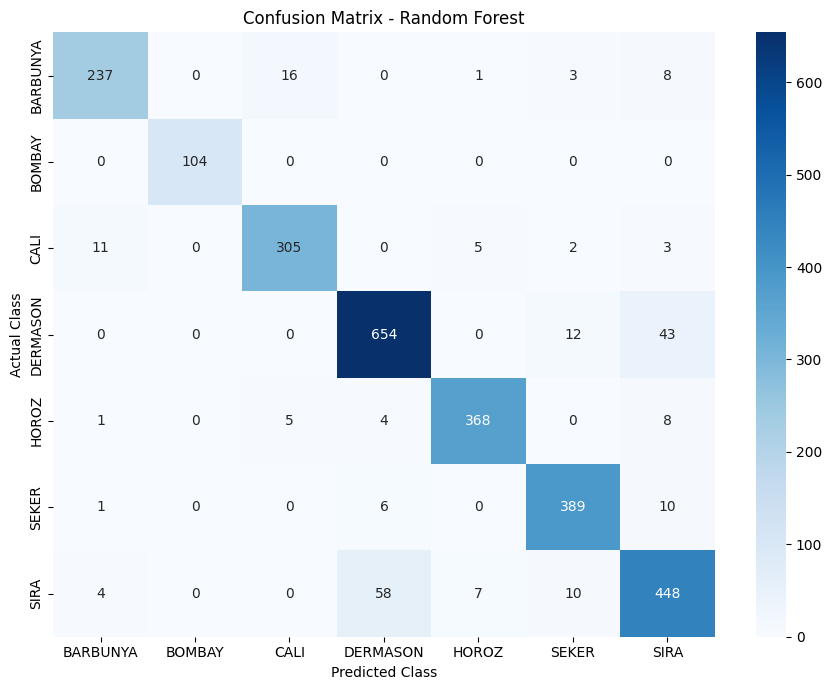

In [ ]:
# Confusion matrix for each model
for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

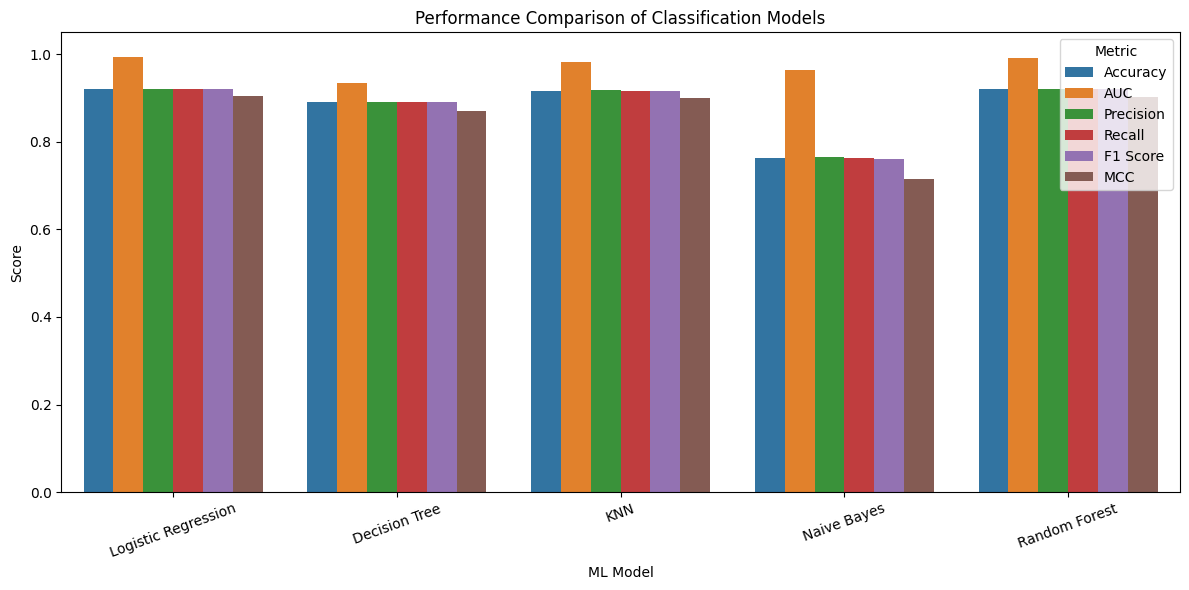

In [ ]:
# Compare the models visually
plt.figure(figsize=(12, 6))

results_melted = results_df.melt(
    id_vars="ML Model",
    value_vars=[
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1 Score",
        "MCC"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="ML Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1.05)
plt.title("Performance Comparison of Classification Models")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# Create a test CSV for Streamlit
test_data = X_test.copy()

test_data["Class"] = label_encoder.inverse_transform(y_test)

test_data.to_csv(
    "test_data.csv",
    index=False
)

print("test_data.csv created successfully!")
print("Shape:", test_data.shape)

test_data.head()

test_data.csv created successfully!
Shape: (2723, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
12803,36002,700.889,257.888986,178.268649,1.446631,0.722605,36368,214.100841,0.797386,0.989936,0.920954,0.830205,0.007163,0.002099,0.689241,0.997078,DERMASON
3713,183825,1594.423,582.225240,402.762055,1.445581,0.722124,185116,483.790512,0.797852,0.993026,0.908672,0.830934,0.003167,0.000931,0.690451,0.998102,BOMBAY
8974,45595,801.717,301.092828,193.505323,1.555992,0.766138,46054,240.942643,0.769926,0.990033,0.891425,0.800227,0.006604,0.001670,0.640363,0.996401,SIRA
1743,45084,763.811,261.138204,219.977872,1.187111,0.538882,45425,239.588672,0.773098,0.992493,0.971092,0.917478,0.005792,0.002532,0.841767,0.999271,SEKER
2303,61645,952.199,335.139136,235.843970,1.421021,0.710478,62499,280.158619,0.795522,0.986336,0.854382,0.835947,0.005437,0.001638,0.698808,0.993020,BARBUNYA


In [ ]:
#Save all trained models
os.makedirs("model", exist_ok=True)
model_file_names = {
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "KNN": "knn.pkl",
    "Naive Bayes": "naive_bayes.pkl",
    "Random Forest": "random_forest.pkl"
}

for model_name, model in trained_models.items():

    file_path = os.path.join(
        "model",
        model_file_names[model_name]
    )

    joblib.dump(model, file_path)

    print("Saved:", file_path)

Saved: model/logistic_regression.pkl
Saved: model/decision_tree.pkl
Saved: model/knn.pkl
Saved: model/naive_bayes.pkl
Saved: model/random_forest.pkl


In [ ]:
# Save the Label Encoder
joblib.dump(
    label_encoder,
    "model/label_encoder.pkl"
)

print("Label encoder saved.")

Label encoder saved.


In [ ]:
# Save the metrics
results_df.to_csv(
    "model/model_metrics.csv",
    index=False
)

print("Metrics saved successfully.")

Metrics saved successfully.


In [ ]:
# Verify everything
print("Files created:")
print("-" * 40)

for root, dirs, files in os.walk("."):
    for file in files:

        if (
            file.endswith(".pkl")
            or file == "test_data.csv"
            or file == "model_metrics.csv"
        ):
            print(os.path.join(root, file))

Files created:
----------------------------------------
./test_data.csv
./model/knn.pkl
./model/decision_tree.pkl
./model/random_forest.pkl
./model/label_encoder.pkl
./model/naive_bayes.pkl
./model/logistic_regression.pkl
./model/model_metrics.csv


In [ ]:
# Final results table for your assignment
final_table = results_df[
    [
        "ML Model",
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1 Score",
        "MCC"
    ]
].copy()

final_table = final_table.round(4)

print("\nOVERALL WINNER")
print("=" * 40)

winner_name = (
    results_df
    .sort_values("Average Score", ascending=False)
    .iloc[0]["ML Model"]
)

print(winner_name)


OVERALL WINNER
Logistic Regression


In [ ]:
# DOWNLOADING MODEL and test data
from google.colab import files
import shutil
import os

# Create ZIP containing model files
shutil.make_archive(
    "ml_classification_project",
    "zip",
    ".",
    "model"
)

files.download("ml_classification_project.zip")
files.download("test_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>